Task-1: Regression Analysis

1. Importing Librabries

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

2. Load the dataset

In [2]:
# Boston Housing column names
column_names = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 
                'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'MEDV']

# Load dataset (whitespace delimited, no header)
df = pd.read_csv('House Prediction Data Set.csv', delim_whitespace=True, 
                 header=None, names=column_names)

# Define features (X) and target (y)
X = df.drop('MEDV', axis=1)
y = df['MEDV']

3. Training and Evaluation

In [3]:
# Split into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit the Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions and evaluate metrics
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R-squared Score (R2): {r2:.2f}")

Mean Squared Error (MSE): 24.29
R-squared Score (R2): 0.67


4. Interpret the Coefficients

In [4]:
# Create a dataframe to view coefficients and their impact
coef_df = pd.DataFrame({'Feature': X.columns, 'Coefficient': model.coef_})
print(coef_df.sort_values(by='Coefficient', ascending=False))

    Feature  Coefficient
5        RM     4.438835
3      CHAS     2.784438
8       RAD     0.262430
2     INDUS     0.040381
1        ZN     0.030110
11        B     0.012351
6       AGE    -0.006296
9       TAX    -0.010647
0      CRIM    -0.113056
12    LSTAT    -0.508571
10  PTRATIO    -0.915456
7       DIS    -1.447865
4       NOX   -17.202633


Task 2: Time-Series Analysis

1. Plotting

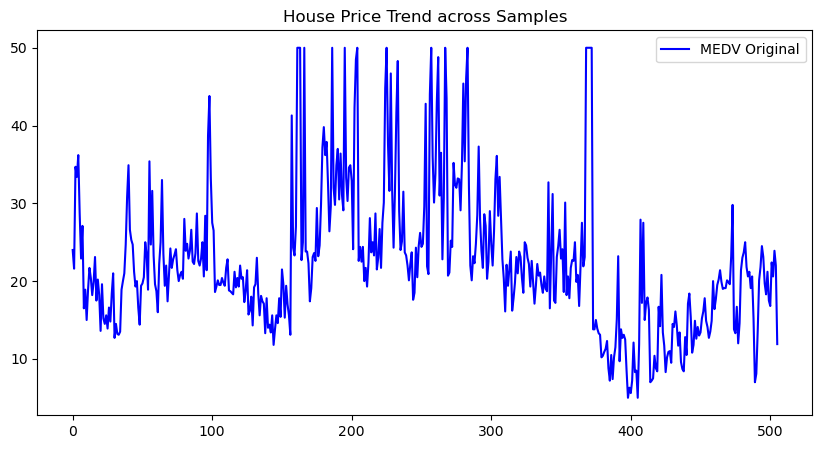

In [5]:
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# Plot the time-series (Row Index as Time Proxy)
plt.figure(figsize=(10, 5))
plt.plot(df['MEDV'], color='blue', label='MEDV Original')
plt.title('House Price Trend across Samples')
plt.legend()
plt.show()


2. Decomposition

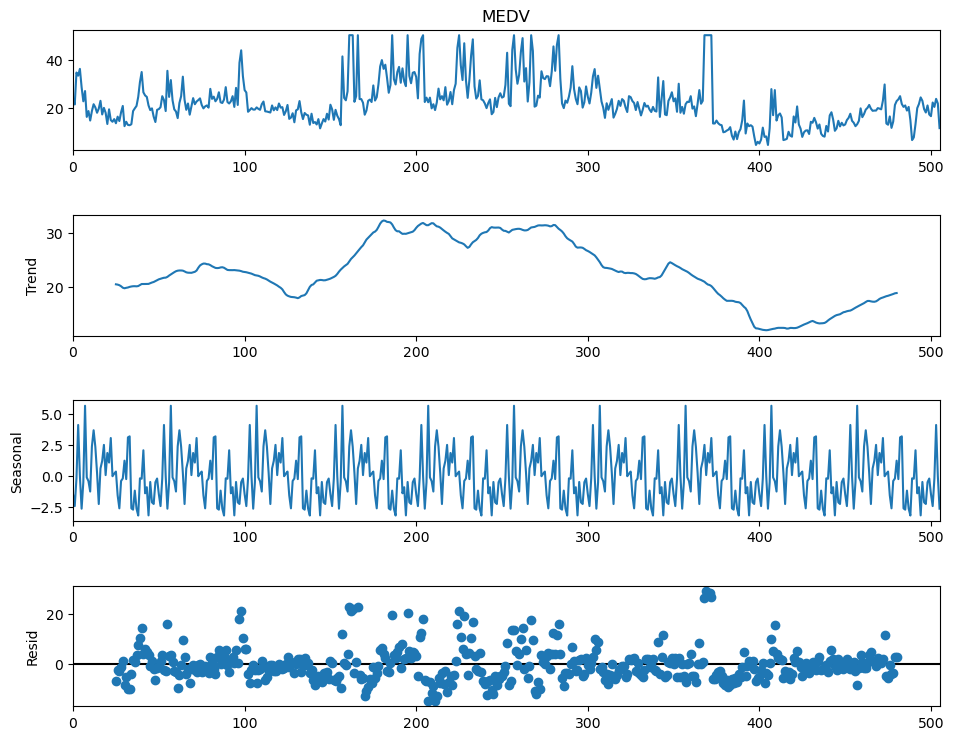

In [6]:
# Decompose the series (using a hypothetical period of 50)
result = seasonal_decompose(df['MEDV'], model='additive', period=50)
fig = result.plot()
fig.set_size_inches(10, 8)
plt.show()

3. Moving Average Smoothing

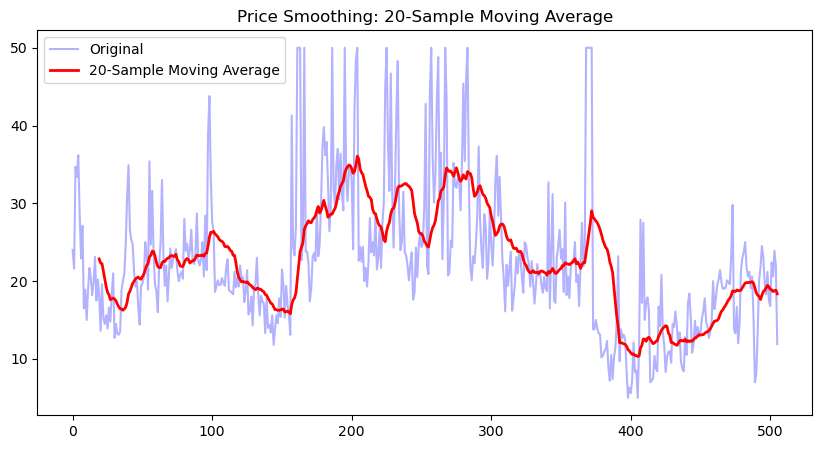

In [7]:
# Perform 20-sample moving average smoothing
ma_window = 20
df['MEDV_Smoothed'] = df['MEDV'].rolling(window=ma_window).mean()

# Plot Original vs Smoothed Price
plt.figure(figsize=(10, 5))
plt.plot(df['MEDV'], label='Original', alpha=0.3, color='blue')
plt.plot(df['MEDV_Smoothed'], label=f'{ma_window}-Sample Moving Average', color='red', linewidth=2)
plt.title(f'Price Smoothing: {ma_window}-Sample Moving Average')
plt.legend()
plt.show()